In [1]:
import os
import numpy as np
import getdist
from getdist import plots, MCSamples
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib import cm
from pathlib import Path

In [2]:
def phi2_final(c):
    """
    Calculates phi^2_final based on the coupling constant c (xi).
    
    Formula:
    0.5 * (4. - 1./xi + sqrt(1 + 24*xi + 16*xi^2)/xi)
    """
    xi = c
    
    # Calculate the term inside the square root
    # 1 + 24*xi + 16*xi^2
    sqrt_arg = 1.0 + 24.0 * xi + 16.0 * (xi**2)
    sqrt_term = np.sqrt(sqrt_arg)
    
    # Calculate the main bracket
    # 4. - 1./xi + sqrt_term/xi
    bracket = 4.0 - (1.0 / xi) + (sqrt_term / xi)
    
    return 0.5 * bracket

In [3]:
def phi2_initial(N, c):
    """
    Calculates phi^2_initial based on N and c (xi) using the simplified formula.
    
    Formula:
    0.999981 * (phi_f^2 + 8. * N)
    """
    # 1. Get phi_final squared
    phi_f_sq = phi2_final(c)
    
    # 2. Calculate the bracket term
    # phi_f^2 + 8. * N
    bracket = phi_f_sq + 8.0 * N
    
    # 3. Final result
    return 0.999981 * bracket

In [4]:
def ns_func(N, s, c):
    """
    Calculates the scalar spectral index n_s.
    
    Formula:
    (7.9997 * xi) / (1. * xi * phi_i^2 + 1.) - (23.9997 / phi_i^2) + 0.99985
    """
    # 1. Get phi_initial squared
    phi_i_sq = phi2_initial(N, c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate Term 1
    # Numerator: 7.9997 * xi
    term1_num = 7.9997 * xi
    
    # Denominator: 1. * xi * phi_i^2 + 1.
    term1_den = (1.0 * xi * phi_i_sq) + 1.0
    
    term1 = term1_num / term1_den
    
    # 4. Calculate Term 2
    # 23.9997 / phi_i^2
    term2 = 23.9997 / phi_i_sq
    
    # 5. Final calculation
    # Term1 - Term2 + 0.99985
    return term1 - term2 + 0.99985

In [5]:
def alpha_s_func(N, s, c):
    """
    Calculates the running of the scalar spectral index alpha_s 
    as a function of N and c (xi) using specific numerical constants.
    """
    # 1. Get phi_final squared
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi
    xi = c
    
    # --- NUMERATOR ---
    
    # Term 1: xi * phi_f^2 * (0.0312494 * xi * phi_f^2 + 0.499991 * xi * N + 0.0937453)
    term1_inner = (0.0312494 * xi * phi_f_sq) + (0.499991 * xi * N) + 0.0937453
    term1 = xi * phi_f_sq * term1_inner
    
    # Term 2: xi * N * (1.99996 * xi * N + 0.749962)
    term2_inner = (1.99996 * xi * N) + 0.749962
    term2 = xi * N * term2_inner
    
    # Term 3: Constant
    term3 = 0.0468718
    
    numerator = term1 + term2 + term3
    
    # --- DENOMINATOR ---
    
    # Part 1: (0.125 * phi_f^2 + 1. * N)^2
    den_part1_inner = (0.125 * phi_f_sq) + (1.0 * N)
    den_part1 = den_part1_inner**2
    
    # Part 2: (0.125 * xi * phi_f^2 + 1. * xi * N + 0.124998)^2
    den_part2_inner = (0.125 * xi * phi_f_sq) + (1.0 * xi * N) + 0.124998
    den_part2 = den_part2_inner**2
    
    denominator = den_part1 * den_part2
    
    return numerator / denominator

Loading Planck...
Loading ACT...
Calculating trajectories...

Plot saved to alpha_s_vs_ns_4.pdf


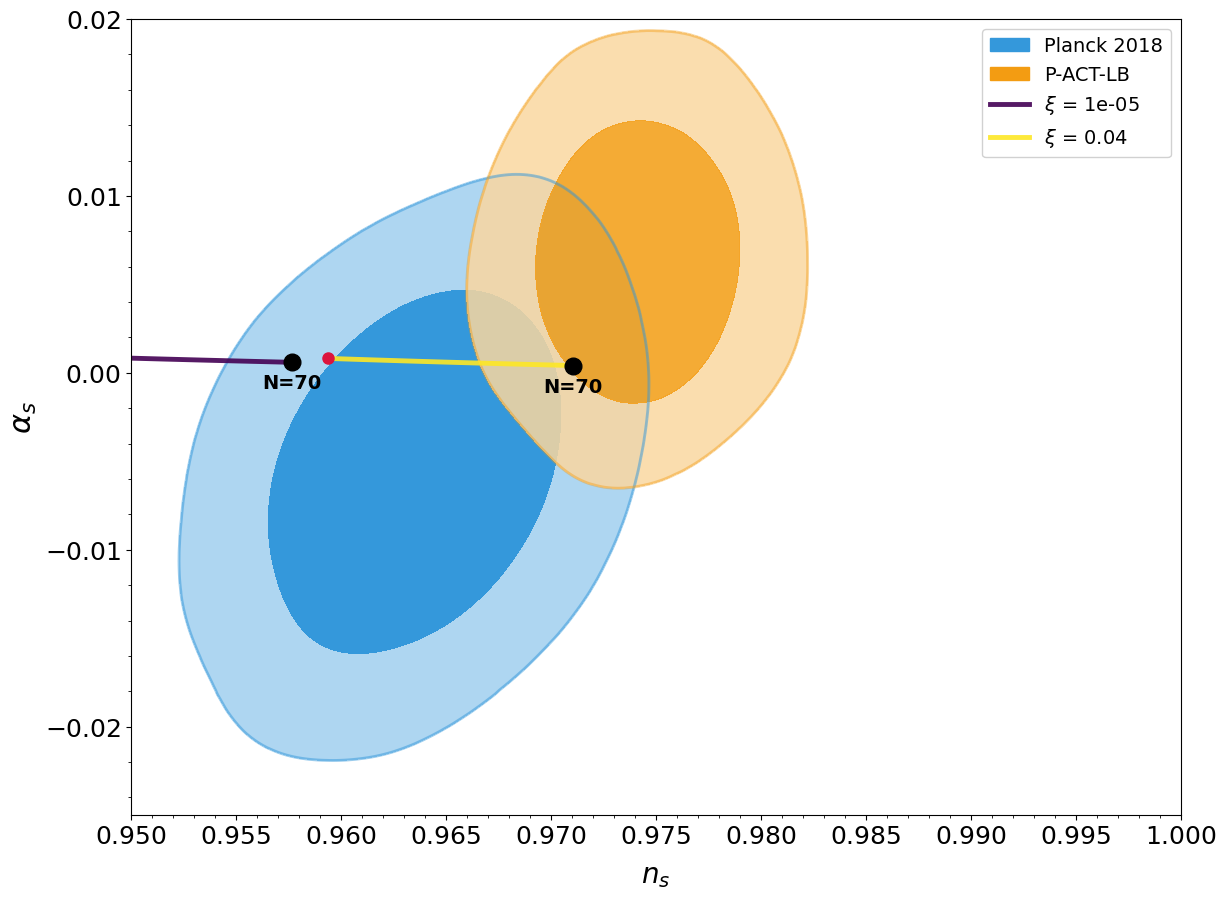

In [6]:
# --- 2. SETUP PATHS ---
#base_dir = os.getcwd()

notebook_dir = Path.cwd()

base_dir = notebook_dir.parents[1] / "data"
act_path = os.path.join(base_dir, 'p-actlite-l-b_nrun_camb', 'p-actlite-l-b_nrun_camb')
planck_path = os.path.join(base_dir, 'COM_CosmoParams_fullGrid_R3.01', 'base_nrun', 'plikHM_TTTEEE_lowl_lowE', 'base_nrun_plikHM_TTTEEE_lowl_lowE')

# --- 3. LOAD DATA ---
samples_to_plot = []

try:
    print("Loading Planck...")
    planck_samples = getdist.mcsamples.loadMCSamples(planck_path, settings={'ignore_rows': 0.3})
    planck_samples.updateSettings({'label': 'Planck 2018'}) 
    samples_to_plot.append(planck_samples)
except:
    print("Warning: Planck data not found.")

try:
    print("Loading ACT...")
    act_samples = getdist.mcsamples.loadMCSamples(act_path, settings={'ignore_rows': 0.3})
    act_samples.updateSettings({'label': 'P-ACT-LB'})
    samples_to_plot.append(act_samples)
except:
    print("Warning: ACT data not found.")

# --- 4. PLOT ---
if len(samples_to_plot) > 0:
    g = plots.get_single_plotter(width_inch=12, ratio=0.75)
    
    # Settings
    g.settings.num_plot_contours = 2
    g.settings.axes_fontsize = 18
    g.settings.lab_fontsize = 20
    g.settings.legend_fontsize = 15
    
    # COLORS: Planck (Grey), ACT (Blue)
    g.settings.solid_colors = ['#F39C12','#3498DB'] 

    g.plot_2d(samples_to_plot, param1='ns', param2='nrun', filled=True)
    ax = g.subplots[0,0]

    ax.set_ylabel(r'$\alpha_s$', fontsize=22)
    
    # --- 5. PLOT TRAJECTORIES ---
    print("Calculating trajectories...")
    s_fixed = 0.76
    #c_values = [0.00001,0.0005, 0.001, 0.0015, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.04] 
    c_values = [0.00001,0.04]
    
    line_colors = [cm.viridis(i) for i in np.linspace(0, 1, len(c_values))]
    
    N_range = np.linspace(50, 70, 100) 
    
    for c, color in zip(c_values, line_colors):
        ns_line = []
        alpha_line = []
        for N in N_range:
            ns_line.append(ns_func(N, s_fixed, c))
            alpha_line.append(alpha_s_func(N, s_fixed, c))
        
        ax.plot(ns_line, alpha_line, color=color, lw=3.5, alpha=0.9, label=rf'$\xi$ = {c:.2g}')
        ax.plot(ns_line[0], alpha_line[0], 'o', color='crimson', markersize=8)
        #ax.text(ns_line[0], alpha_line[0] + 0.0015, 'N=50', color='crimson', fontsize=14, weight='bold', ha='center')
        ax.plot(ns_line[-1], alpha_line[-1], 'o', color='black', markersize=12)
        ax.text(ns_line[-1], alpha_line[-1] - 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # Label N=50 and N=70
    ns_0 = ns_func(50, s_fixed, c_values[0])
    al_0 = alpha_s_func(50, s_fixed, c_values[0])
    #ax.text(ns_0, al_0 + 0.0015, 'N=50', color='black', fontsize=14, weight='bold', ha='center')

    ns_end = ns_func(70, s_fixed, c_values[0])
    al_end = alpha_s_func(70, s_fixed, c_values[0])
    #ax.text(ns_end, al_end + 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # --- 6. TICKS & LIMITS ---
    ax.set_xlim(0.95, 1.0)
    ax.set_ylim(-0.025, 0.02)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # --- 7. CREATE LEGEND MANUALLY (FIXED COLORS) ---
    
    # Manually create patches with the CORRECT colors
    planck_patch = mpatches.Patch(color='#3498DB', label='Planck 2018') # Grey
    act_patch = mpatches.Patch(color='#F39C12', label='P-ACT-LB')       # Blue
    
    # Get handles for the trajectory lines
    line_handles, line_labels = ax.get_legend_handles_labels()
    
    # Combine: [Data Patches] + [Line Handles]
    all_handles = [planck_patch, act_patch] + line_handles
    all_labels = ['Planck 2018', 'P-ACT-LB'] + line_labels

    
    ax.legend(handles=all_handles, labels=all_labels, loc='upper right', fontsize=14, framealpha=0.9)

    outfile = 'alpha_s_vs_ns_4.pdf'
    g.export(outfile, dpi=300)
    print(f"\nPlot saved to {outfile}")
else:
    print("No data loaded.")

Loading Planck...
Loading ACT...
Calculating trajectories...

Plot saved to alpha_s_vs_ns_4_zoom.pdf


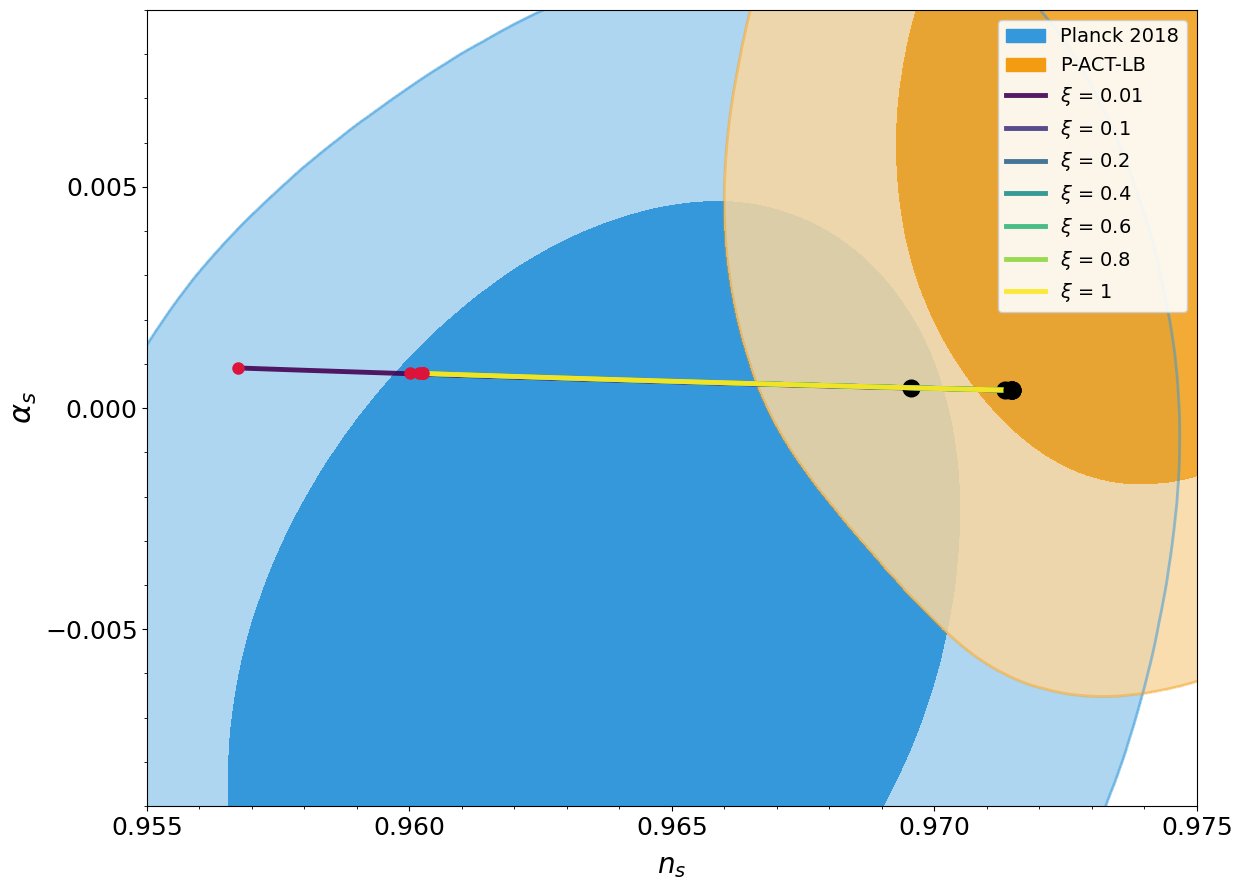

In [7]:
# --- 2. SETUP PATHS ---
notebook_dir = Path.cwd()

base_dir = notebook_dir.parents[1] / "data"
act_path = os.path.join(base_dir, 'p-actlite-l-b_nrun_camb', 'p-actlite-l-b_nrun_camb')
planck_path = os.path.join(base_dir, 'COM_CosmoParams_fullGrid_R3.01', 'base_nrun', 'plikHM_TTTEEE_lowl_lowE', 'base_nrun_plikHM_TTTEEE_lowl_lowE')

# --- 3. LOAD DATA ---
samples_to_plot = []

try:
    print("Loading Planck...")
    planck_samples = getdist.mcsamples.loadMCSamples(planck_path, settings={'ignore_rows': 0.3})
    planck_samples.updateSettings({'label': 'Planck 2018'}) 
    samples_to_plot.append(planck_samples)
except:
    print("Warning: Planck data not found.")

try:
    print("Loading ACT...")
    act_samples = getdist.mcsamples.loadMCSamples(act_path, settings={'ignore_rows': 0.3})
    act_samples.updateSettings({'label': 'P-ACT-LB'})
    samples_to_plot.append(act_samples)
except:
    print("Warning: ACT data not found.")

# --- 4. PLOT ---
if len(samples_to_plot) > 0:
    g = plots.get_single_plotter(width_inch=12, ratio=0.75)
    
    # Settings
    g.settings.num_plot_contours = 2
    g.settings.axes_fontsize = 18
    g.settings.lab_fontsize = 20
    g.settings.legend_fontsize = 15
    
    # COLORS: Planck (Grey), ACT (Blue)
    g.settings.solid_colors = ['#F39C12','#3498DB'] 

    g.plot_2d(samples_to_plot, param1='ns', param2='nrun', filled=True)
    ax = g.subplots[0,0]

    ax.set_ylabel(r'$\alpha_s$', fontsize=22)
    
    # --- 5. PLOT TRAJECTORIES ---
    print("Calculating trajectories...")
    s_fixed = 0.76
    #c_values = [0.00001,0.0005, 0.001, 0.0015, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.04] 
    c_values = [0.01,0.1,0.2,0.4,0.6,0.8,1]
    
    line_colors = [cm.viridis(i) for i in np.linspace(0, 1, len(c_values))]
    
    N_range = np.linspace(50, 70, 100) 
    
    for c, color in zip(c_values, line_colors):
        ns_line = []
        alpha_line = []
        for N in N_range:
            ns_line.append(ns_func(N, s_fixed, c))
            alpha_line.append(alpha_s_func(N, s_fixed, c))
        
        ax.plot(ns_line, alpha_line, color=color, lw=3.5, alpha=0.9, label=rf'$\xi$ = {c:.2g}')
        ax.plot(ns_line[0], alpha_line[0], 'o', color='crimson', markersize=8)
        #ax.text(ns_line[0], alpha_line[0] + 0.0015, 'N=50', color='crimson', fontsize=14, weight='bold', ha='center')
        ax.plot(ns_line[-1], alpha_line[-1], 'o', color='black', markersize=12)
        #ax.text(ns_line[-1], alpha_line[-1] - 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # Label N=50 and N=70
    ns_0 = ns_func(50, s_fixed, c_values[0])
    al_0 = alpha_s_func(50, s_fixed, c_values[0])
    #ax.text(ns_0, al_0 + 0.0015, 'N=50', color='black', fontsize=14, weight='bold', ha='center')

    ns_end = ns_func(70, s_fixed, c_values[0])
    al_end = alpha_s_func(70, s_fixed, c_values[0])
    #ax.text(ns_end, al_end + 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # --- 6. TICKS & LIMITS ---
    ax.set_xlim(0.955, 0.975)
    ax.set_ylim(-0.009, 0.009)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # --- 7. CREATE LEGEND MANUALLY (FIXED COLORS) ---
    
    # Manually create patches with the CORRECT colors
    planck_patch = mpatches.Patch(color='#3498DB', label='Planck 2018') # Grey
    act_patch = mpatches.Patch(color='#F39C12', label='P-ACT-LB')       # Blue
    
    # Get handles for the trajectory lines
    line_handles, line_labels = ax.get_legend_handles_labels()
    
    # Combine: [Data Patches] + [Line Handles]
    all_handles = [planck_patch, act_patch] + line_handles
    all_labels = ['Planck 2018', 'P-ACT-LB'] + line_labels

    
    ax.legend(handles=all_handles, labels=all_labels, loc='upper right', fontsize=14, framealpha=0.9)

    outfile = 'alpha_s_vs_ns_4_zoom.pdf'
    g.export(outfile, dpi=600)
    print(f"\nPlot saved to {outfile}")
else:
    print("No data loaded.")